In [1]:
#UPLOAD DATASET
from google.colab import files
files.upload()

Saving alzheimer.csv to alzheimer.csv


{'alzheimer.csv': b'Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF\r\nNondemented,M,87,14,2,27,0,1987,0.696,0.883\r\nNondemented,M,88,14,2,30,0,2004,0.681,0.876\r\nDemented,M,75,12,,23,0.5,1678,0.736,1.046\r\nDemented,M,76,12,,28,0.5,1738,0.713,1.01\r\nDemented,M,80,12,,22,0.5,1698,0.701,1.034\r\nNondemented,F,88,18,3,28,0,1215,0.71,1.444\r\nNondemented,F,90,18,3,27,0,1200,0.718,1.462\r\nNondemented,M,80,12,4,28,0,1689,0.712,1.039\r\nNondemented,M,83,12,4,29,0.5,1701,0.711,1.032\r\nNondemented,M,85,12,4,30,0,1699,0.705,1.033\r\nDemented,M,71,16,,28,0.5,1357,0.748,1.293\r\nDemented,M,73,16,,27,1,1365,0.727,1.286\r\nDemented,M,75,16,,27,1,1372,0.71,1.279\r\nNondemented,F,93,14,2,30,0,1272,0.698,1.38\r\nNondemented,F,95,14,2,29,0,1257,0.703,1.396\r\nDemented,M,68,12,2,27,0.5,1457,0.806,1.205\r\nDemented,M,69,12,2,24,0.5,1480,0.791,1.186\r\nDemented,F,66,12,3,30,0.5,1447,0.769,1.213\r\nDemented,F,68,12,3,29,0.5,1482,0.752,1.184\r\nNondemented,F,78,16,2,29,0,1333,0.748,1.316\r\nNondemented,F

In [2]:
#Load clinical data
import pandas as pd

df = pd.read_csv("alzheimer.csv")

In [4]:
#Separate columns
import numpy as np

# Separate numeric and categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [5]:
#Fill missing values properly
# Fill numeric with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical with most frequent (mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
#Encode categorical data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [9]:
#Preprocess
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load
df = pd.read_csv("alzheimer.csv")

# 1. Separate numeric & categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# 2. Fill missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Separate target
y = df['Group']   # ⚠️ change if your column name is different
X = df.drop('Group', axis=1)

# 4. Encode target
y = LabelEncoder().fit_transform(y)

# 5. Encode categorical features
for col in X.select_dtypes(exclude=np.number).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# 6. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
#Train model
from sklearn.ensemble import RandomForestClassifier

clinical_model = RandomForestClassifier()
clinical_model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
#Test
from sklearn.metrics import accuracy_score

pred = clinical_model.predict(X_test)
print(accuracy_score(y_test, pred))

0.88


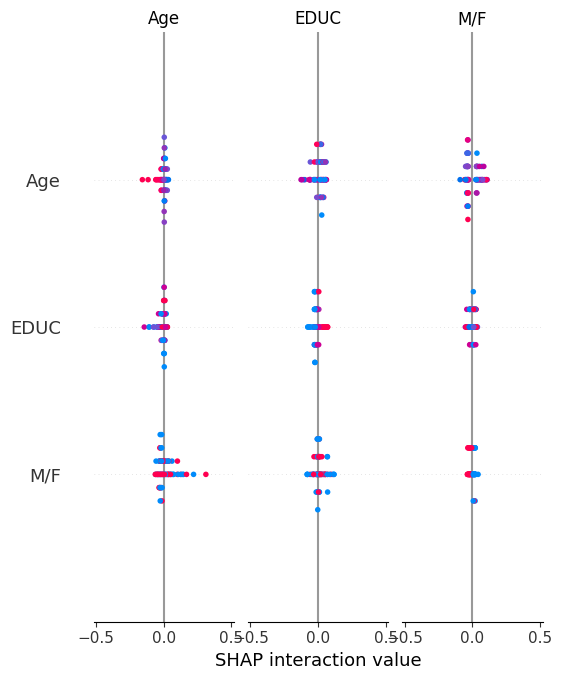

In [12]:
#Explain (VERY IMPORTANT)
import shap

explainer = shap.TreeExplainer(clinical_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [13]:
#ave Both Models
#From clinical notebook:

import joblib
joblib.dump(clinical_model, "clinical_model.pkl")

['clinical_model.pkl']

In [14]:
##Download models to your system
from google.colab import files

files.download('clinical_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def plot_accuracy_graphs():
    plotted = False

    # 1) Keras training history plot (accuracy vs validation accuracy)
    history_candidates = []
    for name, value in globals().items():
        hist = getattr(value, "history", None)
        if isinstance(hist, dict):
            acc_key = "accuracy" if "accuracy" in hist else ("acc" if "acc" in hist else None)
            val_acc_key = "val_accuracy" if "val_accuracy" in hist else ("val_acc" if "val_acc" in hist else None)
            if acc_key:
                history_candidates.append((name, hist, acc_key, val_acc_key))

    if history_candidates:
        name, hist, acc_key, val_acc_key = history_candidates[0]
        epochs = range(1, len(hist[acc_key]) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[acc_key], marker="o", label="Train Accuracy")
        if val_acc_key:
            plt.plot(epochs, hist[val_acc_key], marker="o", label="Validation Accuracy")
        plt.title(f"Accuracy Curve ({name})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plotted = True

    # 2) Sklearn-style final accuracy bar chart from y_test*/y_pred* pairs
    accuracy_items = []
    for test_name, y_true in globals().items():
        if not test_name.startswith("y_test"):
            continue
        suffix = test_name[len("y_test"):]
        pred_name = f"y_pred{suffix}"
        if pred_name in globals():
            y_hat = globals()[pred_name]
            try:
                score = accuracy_score(y_true, y_hat)
                label = suffix.replace("_", " ").strip().title() or "Model"
                accuracy_items.append((label, score))
            except Exception:
                pass

    if accuracy_items:
        labels = [item[0] for item in accuracy_items]
        scores = [item[1] for item in accuracy_items]

        plt.figure(figsize=(8, 5))
        bars = plt.bar(labels, scores)
        plt.ylim(0, 1)
        plt.ylabel("Accuracy")
        plt.title("Model Accuracy Comparison")
        plt.grid(axis="y", alpha=0.3)

        for bar, score in zip(bars, scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 0.01,
                f"{score:.3f}",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()
        plotted = True

    if not plotted:
        print("No accuracy data found yet. Run training/evaluation cells first, then run this cell.")


plot_accuracy_graphs()

In [ ]:
import matplotlib.pyplot as plt

history_candidates = [
    globals().get('history'),
    globals().get('training_history'),
    globals().get('model_history'),
    globals().get('hist'),
]

history_obj = next((item for item in history_candidates if item is not None), None)

if history_obj is not None and hasattr(history_obj, 'history'):
    history_dict = history_obj.history
elif isinstance(history_obj, dict):
    history_dict = history_obj
else:
    history_dict = None

if history_dict and 'accuracy' in history_dict:
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict['accuracy'], label='Training Accuracy')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    metrics = []
    labels = []
    for label, value_name in [('Training', 'train_accuracy'), ('Validation/Test', 'val_accuracy')]:
        value = globals().get(value_name)
        if value is not None:
            labels.append(label)
            metrics.append(value)

    if metrics:
        plt.figure(figsize=(6, 4))
        plt.bar(labels, metrics, color=['#1f77b4', '#ff7f0e'])
        plt.ylim(0, 1)
        plt.title('Accuracy Summary')
        plt.ylabel('Accuracy')
        plt.grid(axis='y', alpha=0.3)
        plt.show()
    else:
        print('No accuracy history or accuracy variables found in this notebook yet.')


In [ ]:
# Alzheimer clinical metrics + confusion matrix (local run)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)

# 1) Load dataset from workspace
cwd = os.getcwd()
csv_candidates = [
    os.path.join("datasets", "alzheimer_clinical_data.csv"),
    os.path.join("..", "datasets", "alzheimer_clinical_data.csv"),
    os.path.join(cwd, "datasets", "alzheimer_clinical_data.csv"),
    os.path.join(cwd, "..", "datasets", "alzheimer_clinical_data.csv"),
    "alzheimer.csv",
]
csv_candidates = [os.path.normpath(p) for p in csv_candidates]
csv_path = next((p for p in csv_candidates if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError("Clinical dataset not found. Tried: " + ", ".join(csv_candidates))

df = pd.read_csv(csv_path)
print(f"Loaded dataset: {csv_path}")
print(f"Shape: {df.shape}")

# 2) Choose target column
preferred_targets = ["Group", "Diagnosis", "Class", "Label", "Target", "Outcome"]
target_col = next((c for c in preferred_targets if c in df.columns), df.columns[-1])
print(f"Target column: {target_col}")

# 3) Fill missing values
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

if num_cols:
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
for col in cat_cols:
    mode_val = df[col].mode()
    df[col] = df[col].fillna(mode_val.iloc[0] if not mode_val.empty else "Unknown")

# 4) Split features/target
X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

# 5) Encode categorical features
for col in X.select_dtypes(exclude=np.number).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 6) Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw.astype(str))
class_names = label_encoder.classes_.tolist()

# 7) Train/test split + model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clinical_model = RandomForestClassifier(n_estimators=300, random_state=42)
clinical_model.fit(X_train, y_train)

y_pred = clinical_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# 8) Metrics graph
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(class_names)), zero_division=0
)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(12, 5))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")
plt.xticks(x, class_names, rotation=20)
plt.ylim(0, 1.0)
plt.title(f"Alzheimer Clinical Class-wise Metrics (Accuracy={acc:.3f})")
plt.xlabel("Class")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 9) Confusion matrix graph
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Alzheimer Clinical Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

FileNotFoundError: Clinical dataset not found. Tried: datasets\alzheimer_clinical_data.csv, alzheimer.csv